# Support Vector Machine [for Brest cancer detection]

In [70]:
import pandas as pd 
import numpy as np  

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix  , accuracy_score


In [71]:
from sklearn.datasets import load_breast_cancer
df = load_breast_cancer() 

In [72]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target


In [73]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [74]:
df.drop( columns='mean texture', inplace=True)


In [75]:
df.drop(columns='mean smoothness', inplace=True)
df.drop(columns='mean compactness', inplace=True)
df.drop(columns='mean symmetry', inplace=True)
df.drop(columns='mean fractal dimension', inplace=True)
df.drop(columns='worst texture', inplace=True)
df.drop(columns='worst smoothness', inplace=True)

In [76]:
df.drop(columns='worst compactness', inplace=True)
df.drop(columns='worst symmetry', inplace=True)
df.drop(columns='worst fractal dimension', inplace=True)


In [77]:
df.head()

,mean radius,mean perimeter,mean area,mean concavity,mean concave points,radius error,texture error,perimeter error,area error,smoothness error,...,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst perimeter,worst area,worst concavity,worst concave points,target
0,17.99,122.80,1001.0,0.3001,0.14710,1.0950,0.9053,8.589,153.40,0.006399,...,0.05373,0.01587,0.03003,0.006193,25.38,184.60,2019.0,0.7119,0.2654,0
1,20.57,132.90,1326.0,0.0869,0.07017,0.5435,0.7339,3.398,74.08,0.005225,...,0.01860,0.01340,0.01389,0.003532,24.99,158.80,1956.0,0.2416,0.1860,0
2,19.69,130.00,1203.0,0.1974,0.12790,0.7456,0.7869,4.585,94.03,0.006150,...,0.03832,0.02058,0.02250,0.004571,23.57,152.50,1709.0,0.4504,0.2430,0
3,11.42,77.58,386.1,0.2414,0.10520,0.4956,1.1560,3.445,27.23,0.009110,...,0.05661,0.01867,0.05963,0.009208,14.91,98.87,567.7,0.6869,0.2575,0
4,20.29,135.10,1297.0,0.1980,0.10430,0.7572,0.7813,5.438,94.44,0.011490,...,0.05688,0.01885,0.01756,0.005115,22.54,152.20,1575.0,0.4000,0.1625,0


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean perimeter           569 non-null    float64
 2   mean area                569 non-null    float64
 3   mean concavity           569 non-null    float64
 4   mean concave points      569 non-null    float64
 5   radius error             569 non-null    float64
 6   texture error            569 non-null    float64
 7   perimeter error          569 non-null    float64
 8   area error               569 non-null    float64
 9   smoothness error         569 non-null    float64
 10  compactness error        569 non-null    float64
 11  concavity error          569 non-null    float64
 12  concave points error     569 non-null    float64
 13  symmetry error           569 non-null    float64
 14  fractal dimension error  5

In [79]:
df.drop(columns='radius error', inplace=True)
df.drop(columns='texture error', inplace=True)
df.drop(columns='perimeter error', inplace=True)
df.drop(columns='area error', inplace=True)    


In [80]:
df.drop(columns='smoothness error', inplace=True)
df.drop(columns='compactness error', inplace=True)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean perimeter           569 non-null    float64
 2   mean area                569 non-null    float64
 3   mean concavity           569 non-null    float64
 4   mean concave points      569 non-null    float64
 5   concavity error          569 non-null    float64
 6   concave points error     569 non-null    float64
 7   symmetry error           569 non-null    float64
 8   fractal dimension error  569 non-null    float64
 9   worst radius             569 non-null    float64
 10  worst perimeter          569 non-null    float64
 11  worst area               569 non-null    float64
 12  worst concavity          569 non-null    float64
 13  worst concave points     569 non-null    float64
 14  target                   5

In [82]:
df.head()

,mean radius,mean perimeter,mean area,mean concavity,mean concave points,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst perimeter,worst area,worst concavity,worst concave points,target
0,17.99,122.80,1001.0,0.3001,0.14710,0.05373,0.01587,0.03003,0.006193,25.38,184.60,2019.0,0.7119,0.2654,0
1,20.57,132.90,1326.0,0.0869,0.07017,0.01860,0.01340,0.01389,0.003532,24.99,158.80,1956.0,0.2416,0.1860,0
2,19.69,130.00,1203.0,0.1974,0.12790,0.03832,0.02058,0.02250,0.004571,23.57,152.50,1709.0,0.4504,0.2430,0
3,11.42,77.58,386.1,0.2414,0.10520,0.05661,0.01867,0.05963,0.009208,14.91,98.87,567.7,0.6869,0.2575,0
4,20.29,135.10,1297.0,0.1980,0.10430,0.05688,0.01885,0.01756,0.005115,22.54,152.20,1575.0,0.4000,0.1625,0


In [83]:
df.tail()

,mean radius,mean perimeter,mean area,mean concavity,mean concave points,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst perimeter,worst area,worst concavity,worst concave points,target
564,21.56,142.00,1479.0,0.24390,0.13890,0.05198,0.02454,0.01114,0.004239,25.450,166.10,2027.0,0.4107,0.2216,0
565,20.13,131.20,1261.0,0.14400,0.09791,0.03950,0.01678,0.01898,0.002498,23.690,155.00,1731.0,0.3215,0.1628,0
566,16.60,108.30,858.1,0.09251,0.05302,0.04730,0.01557,0.01318,0.003892,18.980,126.70,1124.0,0.3403,0.1418,0
567,20.60,140.10,1265.0,0.35140,0.15200,0.07117,0.01664,0.02324,0.006185,25.740,184.60,1821.0,0.9387,0.2650,0
568,7.76,47.92,181.0,0.00000,0.00000,0.00000,0.00000,0.02676,0.002783,9.456,59.16,268.6,0.0000,0.0000,1


In [84]:
df.isnull().sum()

mean radius                0
mean perimeter             0
mean area                  0
mean concavity             0
mean concave points        0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst perimeter            0
worst area                 0
worst concavity            0
worst concave points       0
target                     0
dtype: int64

In [85]:
import seaborn as sns

<Axes: xlabel='target', ylabel='count'>

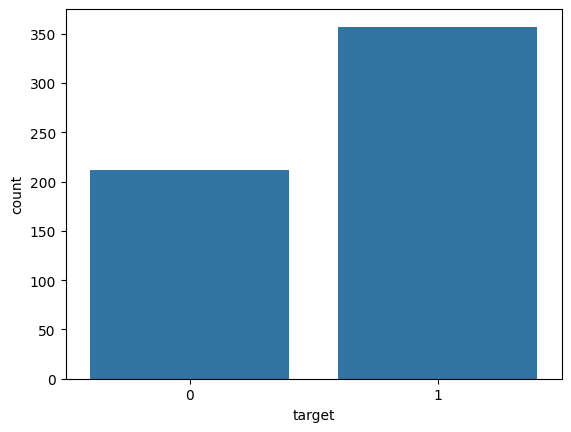

In [86]:
sns.countplot(x='target', data=df)


<Axes: xlabel='mean radius', ylabel='Count'>

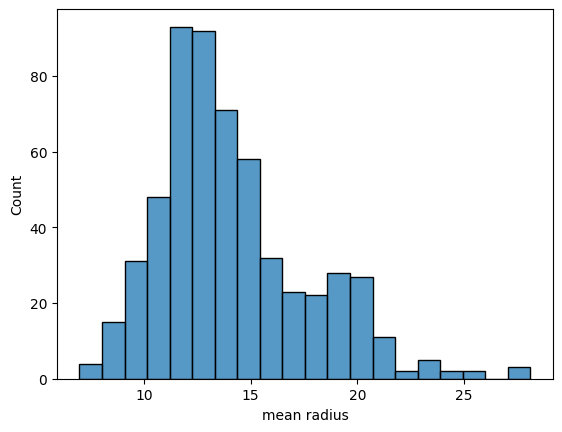

In [87]:
sns.histplot(df['mean radius'], bins=20)


In [88]:
X = df.drop('target', axis=1)
y = df['target']


In [89]:
class BreastCancerSVC:
    def __init__(self, df):
        self.df = df
        self.scaler = StandardScaler()
        self.model = SVC(kernel='rbf', C=1.0, gamma='scale')

    def split_data(self):
        X = self.df.drop('target', axis=1)
        y = self.df['target']
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.25, random_state=42
        )

    def scale_data(self):
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

    def train(self):
        self.model.fit(self.X_train, self.y_train)

    def evaluate(self):
        y_pred = self.model.predict(self.X_test)
        print("Accuracy:", accuracy_score(self.y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(self.y_test, y_pred))

In [90]:
svc = BreastCancerSVC(df)

svc.split_data()
svc.scale_data()
svc.train()
svc.evaluate()


Accuracy: 0.965034965034965
Confusion Matrix:
 [[51  3]
 [ 2 87]]


In [107]:
df.head()

,mean radius,mean perimeter,mean area,mean concavity,mean concave points,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst perimeter,worst area,worst concavity,worst concave points,target
0,17.99,122.80,1001.0,0.3001,0.14710,0.05373,0.01587,0.03003,0.006193,25.38,184.60,2019.0,0.7119,0.2654,0
1,20.57,132.90,1326.0,0.0869,0.07017,0.01860,0.01340,0.01389,0.003532,24.99,158.80,1956.0,0.2416,0.1860,0
2,19.69,130.00,1203.0,0.1974,0.12790,0.03832,0.02058,0.02250,0.004571,23.57,152.50,1709.0,0.4504,0.2430,0
3,11.42,77.58,386.1,0.2414,0.10520,0.05661,0.01867,0.05963,0.009208,14.91,98.87,567.7,0.6869,0.2575,0
4,20.29,135.10,1297.0,0.1980,0.10430,0.05688,0.01885,0.01756,0.005115,22.54,152.20,1575.0,0.4000,0.1625,0


In [115]:
df.tail()

,mean radius,mean perimeter,mean area,mean concavity,mean concave points,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst perimeter,worst area,worst concavity,worst concave points,target
564,21.56,142.00,1479.0,0.24390,0.13890,0.05198,0.02454,0.01114,0.004239,25.450,166.10,2027.0,0.4107,0.2216,0
565,20.13,131.20,1261.0,0.14400,0.09791,0.03950,0.01678,0.01898,0.002498,23.690,155.00,1731.0,0.3215,0.1628,0
566,16.60,108.30,858.1,0.09251,0.05302,0.04730,0.01557,0.01318,0.003892,18.980,126.70,1124.0,0.3403,0.1418,0
567,20.60,140.10,1265.0,0.35140,0.15200,0.07117,0.01664,0.02324,0.006185,25.740,184.60,1821.0,0.9387,0.2650,0
568,7.76,47.92,181.0,0.00000,0.00000,0.00000,0.00000,0.02676,0.002783,9.456,59.16,268.6,0.0000,0.0000,1


In [118]:
import numpy as np

new_sample = np.array([[
7.76,	47.92,	181.0,	0.00000	,0.00000,	0.00000,0.00000,	0.02676,	0.002783	,9.456	,59.16	,268.6	,0.0000	,0.0000	

]])


In [119]:
new_sample_scaled = svc.scaler.transform(new_sample)
prediction = svc.model.predict(new_sample_scaled)

print("Prediction for the new sample:", "Malignant" if prediction[0] == 0 else "Benign")


Prediction for the new sample: Benign


d:\Subjects_Languages\Languages\AICT SureTrust Internship\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
